In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy .stats import boxcox

In [7]:
data = np.random.exponential(scale=2, size=1000)
df = pd.DataFrame({"Salary": data})

In [8]:
df.head()

,Salary
0,2.025653
1,1.228340
2,1.219428
3,2.696793
4,0.335921


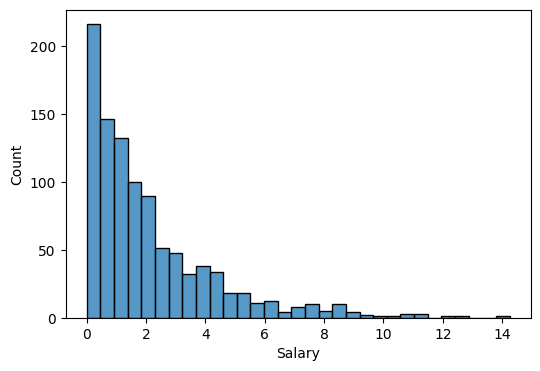

In [9]:
 plt.figure(figsize=(6,4))
 sns.histplot(df.Salary)
 plt.show()

In [10]:
df.Salary.skew()

np.float64(1.8605417978431875)

In [12]:
df["Updated_Salary"],lambda_val = boxcox(df.Salary)
df.head()

,Salary,Updated_Salary
0,2.025653,0.771652
1,1.228340,0.211015
2,1.219428,0.203358
3,2.696793,1.125181
4,0.335921,-0.955408


In [ ]:
lambda_val

np.float64(0.24872707850649062)

In [14]:
df.Updated_Salary.skew()

np.float64(-0.03863907087761408)

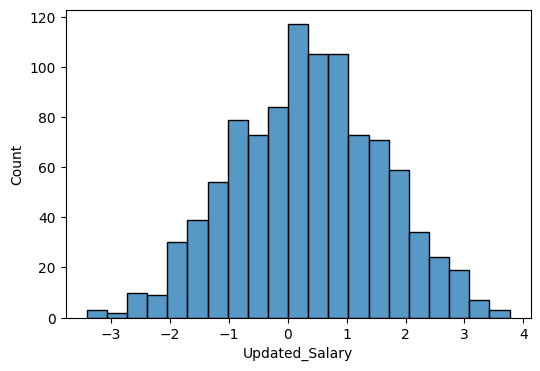

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df.Updated_Salary)
plt.show()


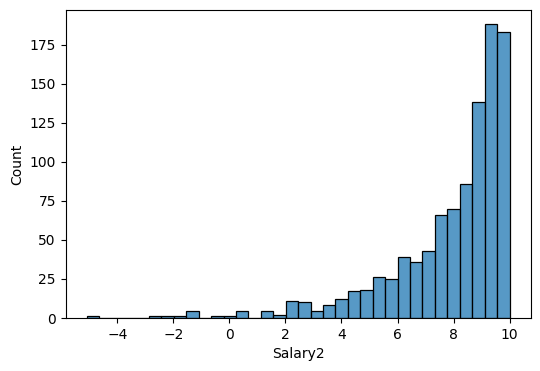

In [29]:
data = np.random.exponential(scale=2, size=1000)
data = 10 - data
df = pd.DataFrame({"Salary2": data})
plt.figure(figsize=(6,4))
sns.histplot(df.Salary2)       
plt.show()

In [30]:
df.Salary2.skew()

np.float64(-1.9412702049453106)

In [31]:
df["reflex_Salary"] = df.Salary2.max() - df.Salary2
df.head()

,Salary2,reflex_Salary
0,8.719350,1.278616
1,6.530887,3.467079
2,8.510959,1.487007
3,8.926275,1.071691
4,8.732000,1.265966


In [32]:
max(df.reflex_Salary), min(df.reflex_Salary)

(15.087725260586032, 0.0)

In [36]:
df["Transformed_Salary"] = np.log(df.reflex_Salary+1)
df.head()

,Salary2,reflex_Salary,Transformed_Salary
0,8.719350,1.278616,0.823568
1,6.530887,3.467079,1.496735
2,8.510959,1.487007,0.911080
3,8.926275,1.071691,0.728365
4,8.732000,1.265966,0.818001


In [37]:
df.Transformed_Salary.skew()

np.float64(0.5137570711203736)

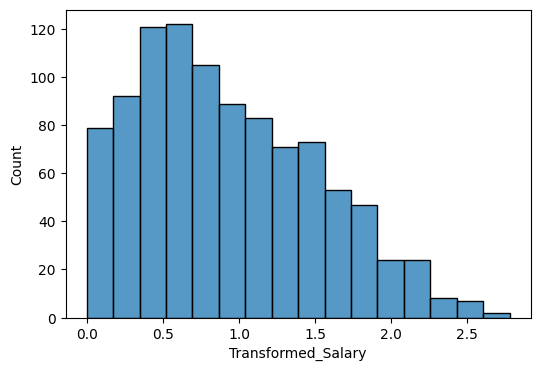

In [38]:
plt.figure(figsize=(6,4))
sns.histplot(df.Transformed_Salary)
plt.show()    

In [47]:
pip install sklearn

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [56]:
import pandas as pd
import numpy as np  
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [41]:
data = pd.read_csv("C:\\Users\\srush\\OneDrive\\Desktop\\AIML Internship\\AIML-Internship\\Day 11\\test2.csv")
data

,Unnamed: 0,Name,Age,Department,Salary
0,0,Alice,25.0,HR,50000.0
1,1,Bob,30.0,IT,60000.0
2,2,Charlie,35.0,Finance,70000.0
3,3,David,NaN,IT,62000.0
4,4,Eve,29.0,HR,NaN
5,5,Alice,25.0,HR,50000.0


In [42]:
data.shape

(6, 5)

In [43]:
data.Age = data.Age.fillna(value=data.Age.mean())
data.Salary = data.Salary.fillna(value=data.Salary.mean())
data

,Unnamed: 0,Name,Age,Department,Salary
0,0,Alice,25.0,HR,50000.0
1,1,Bob,30.0,IT,60000.0
2,2,Charlie,35.0,Finance,70000.0
3,3,David,28.8,IT,62000.0
4,4,Eve,29.0,HR,58400.0
5,5,Alice,25.0,HR,50000.0


In [57]:
Encoder = LabelEncoder()
data["Transformed_Dept"] = Encoder.fit_transform(data.Department)
data

,Unnamed: 0,Name,Age,Department,Salary,scaled_Salary,Transformed_Dept
0,0,Alice,25.0,HR,50000.0,-1.205755,1
1,1,Bob,30.0,IT,60000.0,0.229668,2
2,2,Charlie,35.0,Finance,70000.0,1.665091,0
3,3,David,28.8,IT,62000.0,0.516752,2
4,4,Eve,29.0,HR,58400.0,0.000000,1
5,5,Alice,25.0,HR,50000.0,-1.205755,1


In [59]:
from sklearn.preprocessing import OneHotEncoder

In [61]:
encoder2= OneHotEncoder(sparse_output=False)
encoded = encoder2.fit_transform(data[["Department"]])
encoder2.get_feature_names_out(["Department"])

array(['Department_Finance', 'Department_HR', 'Department_IT'],
      dtype=object)

In [62]:
encoded

array([[0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.]])

In [55]:
from sklearn.preprocessing import StandardScaler , MinMaxScaler

In [52]:
!pip install scikit-learn


Defaulting to user installation because normal site-packages is not writeable
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----------------------- ---------------- 4.7/8.1 MB 42.5 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 36.9 MB/s  0:00:00
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- -------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [64]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler


In [65]:
scaler = StandardScaler()
data["scaled_Salary"] = scaler.fit_transform(data[["Salary"]])
data.head()

,Unnamed: 0,Name,Age,Department,Salary,scaled_Salary,Transformed_Dept
0,0,Alice,25.0,HR,50000.0,-1.205755,10.819798
1,1,Bob,30.0,IT,60000.0,0.229668,11.002117
2,2,Charlie,35.0,Finance,70000.0,1.665091,11.156265
3,3,David,28.8,IT,62000.0,0.516752,11.034906
4,4,Eve,29.0,HR,58400.0,0.000000,10.975088
